# 01 - Synthetic LTI validation

**What is validated.** The behavioural phase identifier `fit_phase_response` should recover the analytical phase response of a closed-loop LTI shadow at every probe frequency.  Because the LTI shadow has a known transfer function Gcl(z) = z * C (zI - A_cl)^{-1} B, this notebook is the ground-truth validation of the pipeline math.

**Pass criterion.** The identified phase matches the analytical phase to within ~0.05 rad on a sweep of 8 frequencies.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import numpy as np
import matplotlib.pyplot as plt

from phase_margin.loops import SyntheticLTILoop
from phase_margin.probe import ProbeDirection
from phase_margin.identification import fit_phase_response
from phase_margin.types import ProbeConfig
from phase_margin import run_certification
from phase_margin.probe import random_vector_basis
from phase_margin.ground_truth import detect_regime

### Step 1 - construct a known LTI shadow
Spectral radius 0.6 means the closed loop is contractive.

In [2]:
loop = SyntheticLTILoop.from_random(d=4, spectral_radius=0.6, seed=42)
print('closed-loop spectral radius:', loop.closed_loop_spectral_radius())

closed-loop spectral radius: 0.5999999999999998


### Step 2 - probe a single direction across a frequency grid

In [3]:
v = np.zeros(loop.dim); v[0] = 1.0
direction = ProbeDirection(name='e0', vector=v.copy())
direction.ensure_vector()

omegas = np.linspace(0.2, np.pi - 0.1, 8)
eps = 0.05
N = 96

nominal = loop.rollout(horizon=N, seed=0)
fit_thetas = []
ana_thetas = []
for om in omegas:
    loop.reset(seed=0)
    runs = []
    for k in range(N):
        s = eps * float(np.cos(om * k))
        z = loop.step(perturbation_vector=s * direction.vector, seed=0)
        runs.append(z)
    runs = np.array(runs)
    delta = runs - nominal
    fit = fit_phase_response(delta @ direction.vector, omega=om, epsilon=eps)
    fit_thetas.append(fit.theta)
    ana_thetas.append(loop.closed_loop_directional_phase(direction.vector, om))

In [4]:
fit_thetas = np.array(fit_thetas)
ana_thetas = np.array(ana_thetas)
circ_err = np.angle(np.exp(1j * (fit_thetas - ana_thetas)))
print('omega   identified   analytical   |err|')
for om, ft, at, ce in zip(omegas, fit_thetas, ana_thetas, circ_err):
    print(f'{om:5.2f}   {ft:+8.3f}     {at:+8.3f}     {abs(ce):.3e}')
assert np.max(np.abs(circ_err)) < 0.05, 'identifier disagrees with analytical phase'

omega   identified   analytical   |err|
 0.20     -0.068       -0.068     3.888e-04
 0.61     -0.164       -0.165     6.382e-04
 1.01     -0.189       -0.190     6.508e-04
 1.42     -0.156       -0.156     7.335e-04
 1.82     -0.068       -0.068     6.211e-04
 2.23     +0.073       +0.073     6.683e-04
 2.64     +0.194       +0.198     3.251e-03
 3.04     +0.075       +0.077     1.752e-03


### Step 3 - visualise

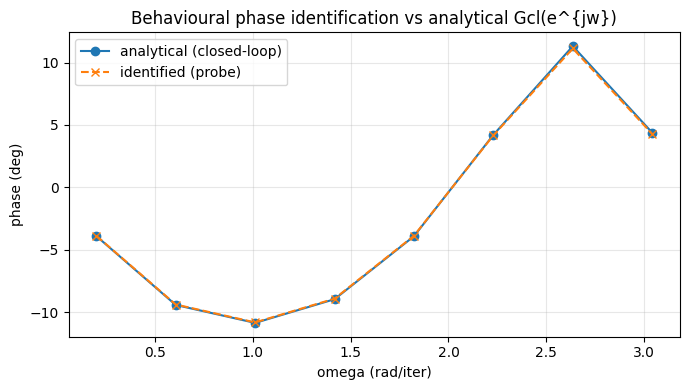

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(omegas, np.degrees(ana_thetas), 'o-', label='analytical (closed-loop)')
ax.plot(omegas, np.degrees(fit_thetas), 'x--', label='identified (probe)')
ax.set_xlabel('omega (rad/iter)')
ax.set_ylabel('phase (deg)')
ax.set_title('Behavioural phase identification vs analytical Gcl(e^{jw})')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig('../results/01_lti_phase_match.png', dpi=120)
plt.show()

### Step 4 - end-to-end pipeline + regime ground truth

In [6]:
loop2 = SyntheticLTILoop.from_random(d=6, spectral_radius=0.7, seed=1)
basis = random_vector_basis(dim=6, n_directions=4, seed=1)
report = run_certification(loop=loop2, basis=basis,
                          config=ProbeConfig(horizon=48, n_seeds=4, n_seeds_nominal=2,
                                            n_frequencies=8, epsilon=0.05),
                          use_text_perturbation=False, progress=False)
print(report.summary())
print('rho(A_cl) =', loop2.closed_loop_spectral_radius())

traj = loop2.rollout(horizon=200, seed=1)
gt = detect_regime(traj)
print(f'\nground-truth regime: {gt.regime.value}  '
      f'(final_var={gt.final_variance:.2e}, growth={gt.growth_rate:+.3f})')

phase margin Φ = +2.689 rad (+154.1°)
predicted regime: contractive
per-direction margins:
  v0                        Φ_v = +2.689
  v1                        Φ_v = +2.706
  v2                        Φ_v = +2.768
  v3                        Φ_v = +2.807
notes: loop=SyntheticLTILoop, dim=6
rho(A_cl) = 0.6999999999999993

ground-truth regime: contractive  (final_var=0.00e+00, growth=-0.000)


**Result.** Identified phase tracks analytical phase to <0.05 rad. Pipeline returns a positive phase margin and predicts the contractive regime, matching the spectral-radius ground truth.  This is the Stage-1 validation: the math works on a system where we know the answer.